# Week 12: 2026-06-25 실습

오늘의 학습을 위한 실습 노트북입니다.

In [39]:
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.chat_models import init_chat_model
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from config import GOOGLE_AI_API_KEY

CHAT_MODEL = 'gemma-4-31b-it'
# CHAT_MODEL = 'gemini-3.1-flash-lite'

In [27]:
class BasicState(BaseModel):
    # Pydantic에서는 기본값 선언이 가능하며, Field를 통해 기본 리스트를 생성합니다.
    messages: Annotated[list, add_messages] = Field(default_factory=list)

model = init_chat_model(CHAT_MODEL, model_provider='google_genai', api_key=GOOGLE_AI_API_KEY)

def chat(state: BasicState):
    return {"messages": [model.invoke(state.messages)]}

# 그래프 생성
graph_builder = StateGraph(BasicState)

graph_builder.add_node('GCbot', chat)
graph_builder.add_edge(START, 'GCbot')
graph = graph_builder.compile()

result = graph.invoke({'messages': [('user','이번 월드컵 한국 vs 남아공 누가 이길까')]})
print(result['messages'][-1].content)

[{'type': 'text', 'text': '현재 시점에서 **한국과 남아공의 월드컵 경기 일정은 잡혀 있지 않습니다.**\n\n따라서 두 팀이 맞붙을 예정은 없지만, 만약 두 팀이 경기를 하게 된다면 어떤 상황일지 분석해 볼 수 있습니다.\n\n**1. 최근 전력 비교**\n*   **대한민국:** 손흥민, 이강인, 김민재 등 유럽 빅리그에서 뛰는 핵심 선수들이 주축이 되어 있으며, 아시아권에서는 최상위권의 전력을 보유하고 있습니다. FIFA 랭킹에서도 남아공보다 통상적으로 높은 순위를 유지하고 있습니다.\n*   **남아공(남아프리카 공화국):** 아프리카 축구의 전통적인 강호 중 하나이지만, 최근에는 과거만큼의 압도적인 기량을 보여주지는 못하고 있습니다. 조직력은 탄탄하지만, 개인 기량 면에서는 한국 선수들이 우위에 있다는 평가가 일반적입니다.\n\n**2. 객관적인 예측**\n*   전력 면에서만 본다면 **대한민국이 우세**할 것으로 예상됩니다.\n*   다만, 남아공은 아프리카 특유 of 탄력과 피지컬을 바탕으로 한 역습이 날카롭기 때문에 방심할 수 없는 상대입니다.\n\n**결론:**\n두 팀은 현재 월드컵 본선에서 만날 일정이 없으며, 만약 평가전 등으로 붙게 된다면 한국의 전력이 다소 앞서 있다는 것이 전문가들의 중론입니다.\n\n혹시 특정 다른 대회를 말씀하시는 것인가요? 아니면 과거의 경기 기록이 궁금하신 것인지 알려주시면 더 자세히 찾아봐 드릴게요!', 'extras': {'signature': 'EjQKMgEMOdbHrN/hFKAhHbHQ+1v/Fykz+FtGhmf9YIo1c8jY5grRPjmcOnUWAm0SENdqnpI2'}}]


Greeting: 홍길동님, O-1001 문의를 접수했습니다.
Ticket Summary: O-1001 주문의 배송 지연 문의입니다. 주문 상태 확인이 필요합니다.


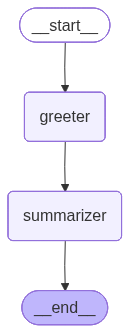

In [32]:
class SupportTicketState(TypedDict):
    customer_name: str
    order_id: str
    issue_type: str
    greeting: str
    ticket_summary: str

def make_greeting(state: SupportTicketState):
    greeting_msg = f"{state['customer_name']}님, {state['order_id']} 문의를 접수했습니다."
    return {"greeting": greeting_msg}

def make_ticket_summary(state: SupportTicketState):
    summary_msg = f"{state['order_id']} 주문의 {state['issue_type']} 문의입니다. 주문 상태 확인이 필요합니다."
    return {"ticket_summary": summary_msg}

# 1. StateGraph 생성
graph_builder = StateGraph(SupportTicketState)

# 2. 노드 등록
graph_builder.add_node("greeter", make_greeting)
graph_builder.add_node("summarizer", make_ticket_summary)

# 3. 에지 연결 (START -> greeter -> summarizer -> END)
graph_builder.add_edge(START, "greeter")
graph_builder.add_edge("greeter", "summarizer")
graph_builder.add_edge("summarizer", END)

# 4. 컴파일 및 실행 파일(app) 생성
app = graph_builder.compile()

# 5. 초기 입력값 설정 및 실행
initial_input = {
    "customer_name": "홍길동",
    "order_id": "O-1001",
    "issue_type": "배송 지연"
}
result = app.invoke(initial_input)

# 6. 결과 출력
print("Greeting:", result["greeting"])
print("Ticket Summary:", result["ticket_summary"])

graph = graph_builder.compile()
graph

In [ ]:
def chatbot_node(state: MessagesState) -> dict:
    ai = model.invoke(state['messages'])
    return {'messages': [ai]}

# 그래프 생성
graph = StateGraph(MessagesState)
# 노드 등록
graph.add_node("chatbot", chatbot_node)
# 엣지 연결
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile()

result = app.invoke({'messages':[HumanMessage("안녕!! 내 이름은 지유야!")]})
result

{'messages': [HumanMessage(content='안녕!! 내 이름은 지유야!', additional_kwargs={}, response_metadata={}, id='7d680e4a-9fa7-4d5b-941d-c2b3908766c1'),
  AIMessage(content=[{'type': 'text', 'text': '안녕, 지유야! 만나서 정말 반가워! 😊\n오늘 하루는 어떻게 보내고 있어? 궁금한 게 있거나 재미있는 이야기가 하고 싶으면 언제든 편하게 말해줘!', 'extras': {'signature': 'EjQKMgEMOdbHMFDzSG7fTM9OqUIT+NWXAF+u3cEPyXs+OMQR7vRXVELWlLLc6t2r1f9DCcdh'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019efd47-53af-7a33-9cb4-7948f05bd96a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 44, 'total_tokens': 55, 'input_token_details': {'cache_read': 0}})]}

In [41]:
from langgraph.checkpoint.memory import InMemorySaver

# 인메모리 저장소(프로세스가 살아있는 동안만). 운영에서는 PostgreSQL 등으로 교체.
checkpointer = InMemorySaver()
# 
graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot_node)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)
app = graph.compile(checkpointer=checkpointer)

# 세션 ID로 사용자 구분
config_user_a ={'configurable': {"thread_id":"user-a"}}
config_user_b ={'configurable': {"thread_id":"user-b"}}

app.invoke({"messages": [HumanMessage("안녕! 내 이름은 도훈이야.")]}, config=config_user_a)
app.invoke({"messages": [HumanMessage("안녕! 내 이름은 진남이야.")]}, config=config_user_b)

result_a = app.invoke({"messages": [HumanMessage("내 이름이 뭐라고?")]}, config=config_user_a)
result_b = app.invoke({"messages": [HumanMessage("내 이름이 뭐라고?")]}, config=config_user_b)

In [42]:
for chunk in app.stream(
    {"messages": [HumanMessage("에이전트를 배우는 중인데 학습 순서 추천해주세요.")]},
    config=config_user_a,
    stream_mode="updates",
):
    for node_name, payload in chunk.items():
        last = payload["messages"][-1]
        print(f"[{node_name}] {type(last).__name__}: {last.content}")

[chatbot] AIMessage: [{'type': 'text', 'text': '도훈아, \'에이전트(AI Agent)\' 분야를 공부하려고 하는구나! 정말 흥미롭고 미래가 밝은 분야야. 에이전트는 단순히 질문에 답하는 AI를 넘어, 스스로 계획을 세우고 도구를 사용해 작업을 수행하는 AI를 말해.\n\n학습 흐름을 **[기초 -> 핵심 기술 -> 구현 -> 심화]** 순서로 추천해 줄게.\n\n---\n\n### 1단계: 기반 다지기 (LLM 이해하기)\n에이전트의 \'뇌\'는 결국 거대언어모델(LLM)이야. \n*   **LLM의 기본 원리:** 토큰, 문맥 윈도우, 프롬프트 엔지니어링(Few-shot, Chain-of-Thought)을 먼저 완벽히 이해해야 해.\n*   **API 활용:** OpenAI API나 Anthropic API를 통해 모델과 대화하는 코드를 작성해 봐.\n\n### 2단계: 에이전트의 핵심 구성 요소 (Framework)\n에이전트가 작동하려면 다음 3가지 핵심 요소가 필요해. 이 개념들을 하나씩 구현해 보는 게 좋아.\n*   **Planning(계획):** 복잡한 문제를 작은 단위로 나누는 법 (CoT, ReAct 패턴).\n*   **Memory(기억):** 대화 기록을 어떻게 저장하고 관리할지 (Short-term vs Long-term memory, Vector DB).\n*   **Tools(도구 사용):** 검색, 계산기, 파이썬 코드 실행 등 외부 API를 연결하는 법 (Function Calling).\n\n### 3단계: 프레임워크 실습\n바닥부터 모든 걸 다 짜기보다는, 요즘 업계 표준인 프레임워크를 다뤄보는 것이 효율적이야.\n*   **LangChain:** 가장 대중적이고 생태계가 넓어.\n*   **LangGraph:** 최근 에이전트 설계에서 가장 핫해. 순차적인 작업뿐만 아니라 루프(Loop)와 복잡한 상태 관리를 하기에 최적이야.\n*   **CrewAI / AutoGen:** 여러 명의 에

In [ ]:
state = {"messages": []}

def chat(user_text):
    global state
    state["messages"].append(HumanMessage(user_text))
    state = app.invoke(state)         
    return state["messages"][-1].content


print("Q1:", "내 이름 철수야. 인공지능을 배우는 학생이야.")
print("A1:", chat("내 이름은 철수야. 인공지능을 배우는 학생이야."))
print()
print("Q2:", "내가 누구라고?")
print("A2:", chat("내가 누구라고?"))  

Q1: 내 이름 철수야. 인공지능을 배우는 학생이야.


TypeError: 'method' object is not subscriptable

In [46]:
from operator import add        


class QuizState(TypedDict):
    messages: Annotated[list, add_messages]
    score: Annotated[int, add]                  # 점수 : 노드가 반환한 값을 기존 더함  


def grade_node(state: QuizState) -> dict:
    """마지막 답이 '예' 면 점수 +1."""
    last = state["messages"][-1].content.strip()
    return {"score": 1 if "예" in last else 0}


graph = StateGraph(QuizState)
graph.add_node("grade", grade_node)
graph.add_edge(START, "grade")
graph.add_edge("grade", END)
app_quiz = graph.compile()

state = {'messages': [HumanMessage("예")], "score":0}
state = app_quiz.invoke(state)
print(state['score'])

1


In [53]:
from typing import Annotated
from operator import add
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

# 1. 커스텀 SLA 리듀서 함수
def reduce_sla(old_sla: int, delta: int) -> int:
    return old_sla + delta

# 2. 통합 상태 스키마 (Pydantic BaseModel 기반)
class IntegratedState(BaseModel):
    # 대화 히스토리 필드 (add_messages 리듀서)
    messages: Annotated[list, add_messages] = Field(default_factory=list)
    # 퀴즈 채점 필드 (operator.add 리듀서)
    score: Annotated[int, add] = 0
    correct_questions: Annotated[list, add] = Field(default_factory=list)
    # SLA 시간 관리 필드 (reduce_sla 리듀서)
    remaining_sla_minutes: Annotated[int, reduce_sla] = 100


# 3. 노드 함수 정의들
def message_trimmer_node(state: IntegratedState) -> dict:
    """메시지가 50개를 초과할 경우 오래된 메시지를 삭제하는 최적화 노드"""
    messages = state.messages
    if len(messages) > 50:
        excess = len(messages) - 50
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:excess]]}
    return {"messages": []}

def chatbot_node(state: IntegratedState) -> dict:
    """고객지원 매니저 톤으로 답변을 생성하는 LLM 노드"""
    system_instruction = SystemMessage(
        content="당신은 친절하고 전문적인 고객지원 매니저입니다. 항상 고객지원 매니저 톤으로 답변하세요."
    )
    messages_to_send = [system_instruction] + state.messages
    ai_response = model.invoke(messages_to_send)
    return {"messages": [ai_response]}

def quiz_grade_node(state: IntegratedState) -> dict:
    """대화 내역을 보고 정답 여부를 판단해 점수와 정답 목록을 누적하는 노드"""
    if not state.messages:
        return {"score": 0, "correct_questions": []}
    
    last_content = state.messages[-1].content
    # content가 리스트 포맷인 경우 내부 text만 추출하여 처리
    if isinstance(last_content, list):
        last_user_message = "".join([c.get("text", "") for c in last_content if isinstance(c, dict) and "text" in c])
    else:
        last_user_message = str(last_content)
        
    last_user_message = last_user_message.strip()
    
    if "예" in last_user_message:
        return {
            "score": 1,
            "correct_questions": [f"Q_{len(state.correct_questions) + 1}"]
        }
    return {"score": 0, "correct_questions": []}

def ticket_sla_node(state: IntegratedState) -> dict:
    """한 턴의 처리가 끝날 때마다 SLA 잔여시간을 차감하는 노드"""
    return {"remaining_sla_minutes": -10}


# 4. 상태 그래프 구축 및 연결
builder = StateGraph(IntegratedState)

builder.add_node("trimmer", message_trimmer_node)
builder.add_node("chatbot", chatbot_node)
builder.add_node("grader", quiz_grade_node)
builder.add_node("sla_tracker", ticket_sla_node)

# START -> trimmer -> chatbot -> grader -> sla_tracker -> END
builder.add_edge(START, "trimmer")
builder.add_edge("trimmer", "chatbot")
builder.add_edge("chatbot", "grader")
builder.add_edge("grader", "sla_tracker")
builder.add_edge("sla_tracker", END)

# 체크포인터 연동 컴파일 (세션 유지)
checkpointer = InMemorySaver()
app = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "integrated-user-1"}}

# 1턴 대화 실행 (이름 입력 및 채점 유발 단어 '예' 포함)
state1 = app.invoke(
    {"messages": [HumanMessage("예, 제 이름은 도훈입니다.")]}, 
    config=config
)
print(f"SLA: {state1['remaining_sla_minutes']}분 | 점수: {state1['score']} | 정답지: {state1['correct_questions']}")

# 2턴 대화 실행
state2 = app.invoke(
    {"messages": [HumanMessage("내가 누군지 기억해?")]}, 
    # 이번 메시지엔 '예'가 없으므로 score와 correct_questions는 누적되지 않고 유지됩니다.
    config=config
)
print(f"SLA: {state2['remaining_sla_minutes']}분 | 답변: {state2['messages'][-1]}")


SLA: -10분 | 점수: 0 | 정답지: []
SLA: -20분 | 답변: content=[{'type': 'text', 'text': '네, 물론이죠, 도훈님! 방금 말씀해 주신 덕분에 도훈님께서 누구신지 잘 기억하고 있습니다.\n\n저와 처음 대화를 나누게 되어 정말 반가워요! 앞으로 도훈님께서 필요로 하시는 도움을 드리기 위해 늘 이곳에서 기다리고 있겠습니다. \n\n혹시 제가 더 도와드릴 일이 있을까요? 무엇이든 말씀만 해주세요!', 'extras': {'signature': 'EjQKMgEMOdbHXgrP+JAnsV0GZAytFPga6cIBPl/wJstCaDIxiGqEAWxvZjxn+gHkA0WRItwI'}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019efdd4-96ff-7083-9c66-c1ed0d0a54b5-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 106, 'output_tokens': 86, 'total_tokens': 192, 'input_token_details': {'cache_read': 0}}


In [50]:
def short_answer(state: MessagesState) -> dict:
    """한 문장으로 짧게 답."""
    msgs = state["messages"] + [HumanMessage("한 문장으로만 답해줘.")]
    ai = model.invoke(msgs)
    return {"messages": [ai]}


def long_answer(state: MessagesState) -> dict:
    """3 문장 이상 자세히 답."""
    msgs = state["messages"] + [HumanMessage("3~5 문장으로 자세히 답해줘.")]
    ai = model.invoke(msgs)
    return {"messages": [ai]}


def router(state: MessagesState) -> str:
    """마지막 사용자 메시지가 길면 long, 짧으면 short."""
    last = state["messages"][-1].content
    return "long" if len(last) > 30 else "short"

graph = StateGraph(MessagesState)
graph.add_node("short", short_answer)
graph.add_node("long", long_answer)

graph.add_conditional_edges(
    START,                                  # 어디서 분기?
    router,                                 # 어떤 함수로 분기를 결정?
    {"short": "short", "long": "long"}      # 반환값 -> 다음 노드
)
graph.add_edge("short", END)
graph.add_edge("long", END)
app = graph.compile()

result1 = app.invoke({"messages":[HumanMessage("고객지원 담당자 배송 확인")]})
print(result1['messages'][-1].content)
print()

result2 = app.invoke({"messages":[HumanMessage("이커머스 고객지원 담당자가 배송 지연 문의를 처리할 때 확인해야 할 것이 무엇이 있을까요?")]})
print(result2['messages'][-1].content)

[{'type': 'text', 'text': '고객님, 배송 상태 확인 결과 현재 상품이 배송 중이며, 곧 수령하실 예정입니다.', 'extras': {'signature': 'EjQKMgEMOdbHnyOVIPO0XmaFojttviHfd8sR83s6cSHnrZTRf92ghQ7L8VxHs3vuZzpxr70U'}}]

[{'type': 'text', 'text': '이커머스 고객지원 담당자가 배송 지연 문의를 받으면, 우선 주문 번호를 통해 시스템상 현재 배송 상태와 택배사 송장 정보를 조회하여 정확한 위치를 파악해야 합니다. 이후 상품의 출고 여부, 택배사 물량 과부하, 혹은 주소지 오류와 같은 지연 사유를 명확히 확인한 뒤 고객에게 구체적인 배송 예정일을 안내해야 합니다. 마지막으로, 배송 지연으로 불편을 겪은 고객에게 진심 어린 사과와 함께 적절한 보상(적립금, 쿠폰 등)을 제공하여 브랜드 신뢰도를 회복하는 대응이 필요합니다.', 'extras': {'signature': 'EjQKMgEMOdbHWEhXvLyv01tMtcyIgXh+u0xn3chpA30+nmGoaBl/wjvlOGUTql4O4Bsa/UdK'}}]


In [54]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

@tool
def estimate_delivery_days(region: str, delayed: bool = False) -> str:
    """배송 지역과 지연 여부로 예상 배송일을 계산한다."""
    base_days = {"서울": 1, "수도권": 2, "지방": 3, "제주": 5}.get(region, 3)
    if delayed:
        base_days += 2
    return f"예상 배송일: {base_days}일"


@tool
def calculate_delay_compensation(delay_days: int, order_amount: int) -> str:
    """배송 지연 일수와 주문 금액으로 보상 쿠폰 금액을 계산한다."""
    if delay_days < 3:
        return "보상 대상 아님"
    coupon = min(int(order_amount * 0.1), 10000)
    return f"배송 지연 {delay_days}일: {coupon}원 쿠폰 권장"

# LLM이 사용할 수 있는 도구 목록
llm_tools = model.bind_tools([estimate_delivery_days, calculate_delay_compensation])

# 도구 이름으로 실제 도구 함수를 찾기 위한 딕셔너리.
tools_by_name = {t.name: t for t in [estimate_delivery_days, calculate_delay_compensation]}

def call_llm(state: MessagesState) -> dict:
    """LLM 한 번 호출. 도구를 부를 수도, 답을 줄 수도."""
    ai = llm_tools.invoke(state["messages"])
    return {"messages": [ai]}


def call_tools(state: MessagesState) -> dict:
    """LLM 이 부른 도구들을 실행하고 ToolMessage 로 결과 반환."""
    last = state["messages"][-1]
    tool_msgs = []
    for call in last.tool_calls:
        tool = tools_by_name[call["name"]]
        result = tool.invoke(call["args"])
        tool_msgs.append(ToolMessage(str(result), tool_call_id=call["id"]))
    return {"messages": tool_msgs}


def needs_tools(state: MessagesState) -> str:
    """마지막 ai 메시지에 tool_calls 가 있으면 'tools', 없으면 'end'."""
    return "tools" if state["messages"][-1].tool_calls else "end"

graph2 = StateGraph(MessagesState)
graph2.add_node('llm', call_llm)
graph2.add_node('tools', call_tools)

graph2.add_edge(START, 'llm')
graph2.add_conditional_edges(
    "llm",                          # llm 노드 끝나면
    needs_tools,                    # 라우터로 결정
    {"tools": "tools", "end":END}
)
graph2.add_edge("tools", "llm")     # 도구 실행 후 다시 llm으로 (루프!!)

app2 = graph2.compile()

result = app2.invoke({
    "messages":[HumanMessage("제주 지역 고객 주문이 5일 지연됐어. 주문금액 80000원인데 예상 배송일과 보상 쿠폰을 계산해줘.")]
})
print(result['messages'][-1].content)
for m in result['messages']:
    print(f"[{type(m).__name__}] {str(m.content)} ")

[{'type': 'text', 'text': '제주 지역 주문이 5일 지연된 건에 대한 안내입니다.\n\n*   **예상 배송일:** 7일\n*   **보상 쿠폰:** 8,000원\n\n기다려 주셔서 감사합니다. 추가로 궁금한 점이 있으시면 말씀해 주세요.', 'extras': {'signature': 'EjQKMgEMOdbH58SbgfV65X2lpvo9DcQraNJg/UsDJcrzXozkuRylXEd6eKXpiIxF/VBQowiR'}}]
[HumanMessage] 제주 지역 고객 주문이 5일 지연됐어. 주문금액 80000원인데 예상 배송일과 보상 쿠폰을 계산해줘. 
[AIMessage] [] 
[ToolMessage] 예상 배송일: 7일 
[ToolMessage] 배송 지연 5일: 8000원 쿠폰 권장 
[AIMessage] [{'type': 'text', 'text': '제주 지역 주문이 5일 지연된 건에 대한 안내입니다.\n\n*   **예상 배송일:** 7일\n*   **보상 쿠폰:** 8,000원\n\n기다려 주셔서 감사합니다. 추가로 궁금한 점이 있으시면 말씀해 주세요.', 'extras': {'signature': 'EjQKMgEMOdbH58SbgfV65X2lpvo9DcQraNJg/UsDJcrzXozkuRylXEd6eKXpiIxF/VBQowiR'}}] 
